In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:

T = 1000           
BATCH_SIZE = 64
IMAGE_SIZE = 28
LEARNING_RATE = 1e-3
EPOCHS = 10
CHANNELS = 1      

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

print(f"Dataset size: {len(train_dataset)} images")
print(f"Batches per epoch: {len(train_loader)}")

Dataset size: 60000 images
Batches per epoch: 938


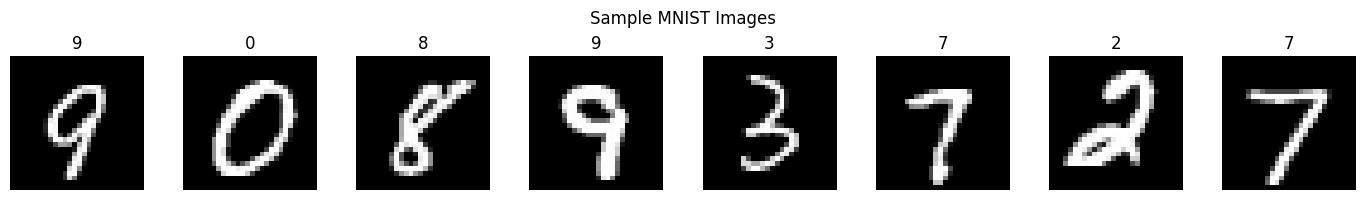

In [28]:
examples = next(iter(train_loader))
images, labels = examples

fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i in range(8):
    axes[i].imshow(images[i].squeeze().numpy() * 0.5 + 0.5, cmap='gray')
    axes[i].set_title(str(labels[i].item()))
    axes[i].axis('off')
plt.suptitle("Sample MNIST Images")
plt.tight_layout()
plt.show()

In [ ]:
class NoiseSchedule:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02):
        self.T = T

        self.betas = torch.linspace(beta_start, beta_end, T).to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)
        self.sqrt_alphas_cumprod       = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

        self.posterior_variance = (
            self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )

    def _extract(self, arr, t, shape):
        batch_size = t.shape[0]
        out = arr.gather(0, t)
        return out.reshape(batch_size, *((1,) * (len(shape) - 1)))

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)

        sqrt_alpha_bar   = self._extract(self.sqrt_alphas_cumprod,           t, x0.shape)
        sqrt_one_minus   = self._extract(self.sqrt_one_minus_alphas_cumprod,  t, x0.shape)

        x_t = sqrt_alpha_bar * x0 + sqrt_one_minus * noise
        return x_t, noise


schedule = NoiseSchedule(T=T)
print("Noise schedule created.")
print(f"  β_0 = {schedule.betas[0]:.5f},  β_T = {schedule.betas[-1]:.5f}")
print(f"  ᾱ_0 = {schedule.alphas_cumprod[0]:.4f},  ᾱ_T = {schedule.alphas_cumprod[-1]:.6f}")

Noise schedule created.
  β_0 = 0.00010,  β_T = 0.02000
  ᾱ_0 = 0.9999,  ᾱ_T = 0.000040


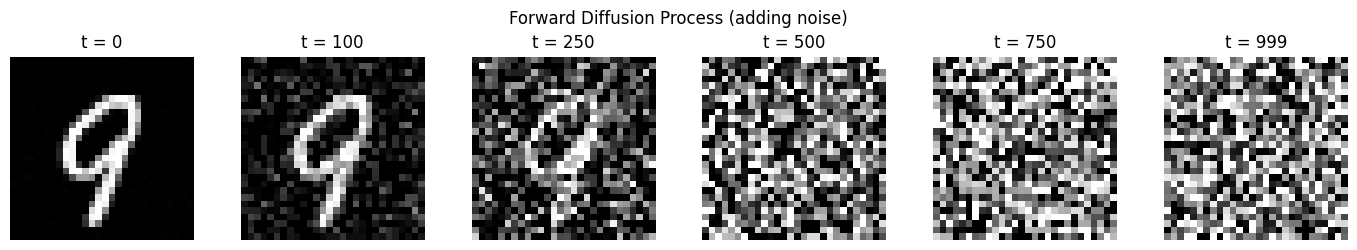

In [ ]:
x0_sample = images[0:1].to(device)   

timesteps_to_show = [0, 100, 250, 500, 750, 999]
fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(14, 2.5))

for ax, t_val in zip(axes, timesteps_to_show):
    t_tensor = torch.tensor([t_val], device=device)
    x_noisy, _ = schedule.q_sample(x0_sample, t_tensor)
    img = x_noisy[0].squeeze().cpu().numpy() * 0.5 + 0.5
    img = np.clip(img, 0, 1)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"t = {t_val}")
    ax.axis('off')

plt.suptitle("Forward Diffusion Process (adding noise)")
plt.tight_layout()
plt.show()

In [ ]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half = self.dim // 2
        freqs = torch.exp(
            -np.log(10000) * torch.arange(half, device=device).float() / (half - 1)
        )
        args = t.float()[:, None] * freqs[None]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)  # (B, dim)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1   = nn.Conv2d(in_ch,  out_ch, 3, padding=1)
        self.norm1   = nn.GroupNorm(8, out_ch)
        self.conv2   = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2   = nn.GroupNorm(8, out_ch)
        self.act     = nn.SiLU()
        self.time_fc = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, out_ch))

        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.act(self.norm1(self.conv1(x)))
        h = h + self.time_fc(t_emb)[:, :, None, None]   
        h = self.act(self.norm2(self.conv2(h)))
        return h + self.shortcut(x)                      


class UNet(nn.Module):
    def __init__(self, img_channels=1, base_ch=64, time_dim=256):
        super().__init__()
        self.time_embed = nn.Sequential(
            SinusoidalPosEmb(base_ch),
            nn.Linear(base_ch, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        self.init_conv = nn.Conv2d(img_channels, base_ch, 3, padding=1)  
        self.enc1 = ResBlock(base_ch,     base_ch,     time_dim)
        self.down1 = nn.Conv2d(base_ch,   base_ch * 2, 3, stride=2, padding=1)  

        self.enc2 = ResBlock(base_ch * 2, base_ch * 2, time_dim)
        self.down2 = nn.Conv2d(base_ch*2, base_ch * 4, 3, stride=2, padding=1)  

        self.enc3 = ResBlock(base_ch * 4, base_ch * 4, time_dim)
        self.down3 = nn.Conv2d(base_ch*4, base_ch * 4, 3, stride=2, padding=1)  

        self.mid1 = ResBlock(base_ch * 4, base_ch * 4, time_dim)
        self.mid2 = ResBlock(base_ch * 4, base_ch * 4, time_dim)

        self.up3      = nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1)
        self.dec3     = ResBlock(base_ch * 4 + base_ch * 4, base_ch * 4, time_dim)

        self.up2      = nn.Conv2d(base_ch * 4, base_ch * 2, 3, padding=1)
        self.dec2     = ResBlock(base_ch * 2 + base_ch * 2, base_ch * 2, time_dim)

        self.up1      = nn.Conv2d(base_ch * 2, base_ch,     3, padding=1)
        self.dec1     = ResBlock(base_ch     + base_ch,     base_ch,     time_dim)

        self.out_norm = nn.GroupNorm(8, base_ch)
        self.out_conv = nn.Conv2d(base_ch, img_channels, 1)

    def forward(self, x, t):
        t_emb = self.time_embed(t)                          

        x0 = self.init_conv(x)

        e1 = self.enc1(x0, t_emb)                          
        e2 = self.enc2(self.down1(e1), t_emb)             
        e3 = self.enc3(self.down2(e2), t_emb)             
        e4 = self.down3(e3)                                

        m  = self.mid1(e4, t_emb)
        m  = self.mid2(m,  t_emb)


        d3 = F.interpolate(m,  size=e3.shape[2:], mode='nearest')
        d3 = self.dec3(torch.cat([self.up3(d3), e3], dim=1), t_emb)  

        d2 = F.interpolate(d3, size=e2.shape[2:], mode='nearest')
        d2 = self.dec2(torch.cat([self.up2(d2), e2], dim=1), t_emb)  

        d1 = F.interpolate(d2, size=e1.shape[2:], mode='nearest')
        d1 = self.dec1(torch.cat([self.up1(d1), e1], dim=1), t_emb)  

        return self.out_conv(F.silu(self.out_norm(d1)))                


model = UNet(img_channels=1, base_ch=64, time_dim=256).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"U-Net created — trainable parameters: {total_params:,}")

with torch.no_grad():
    dummy_x = torch.randn(4, 1, 28, 28, device=device)
    dummy_t = torch.randint(0, T, (4,), device=device)
    out = model(dummy_x, dummy_t)
    print(f"Forward pass OK — output shape: {out.shape}")

U-Net created — trainable parameters: 8,774,081
Forward pass OK — output shape: torch.Size([4, 1, 28, 28])


In [44]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

mse_loss = nn.MSELoss()
print("Optimizer: Adam + CosineAnnealingLR | Loss: MSELoss")

Optimizer: Adam + CosineAnnealingLR | Loss: MSELoss


In [ ]:
def train_one_epoch(model, loader, optimizer, schedule, epoch):
    model.train()
    total_loss = 0.0

    progress = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    for x0, _ in progress:
        x0 = x0.to(device)
        B  = x0.size(0)

        t      = torch.randint(0, T, (B,), device=device)
        x_t, noise = schedule.q_sample(x0, t)

        noise_pred = model(x_t, t)
        loss = mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        progress.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / len(loader)


train_losses = []

for epoch in range(EPOCHS):
    avg_loss = train_one_epoch(model, train_loader, optimizer, schedule, epoch)
    scheduler.step()
    train_losses.append(avg_loss)
    lr = optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}]  Avg Loss: {avg_loss:.4f}  LR: {lr:.6f}")

print("\nTraining complete!")

Epoch [01/10]  Avg Loss: 0.0644  LR: 0.000976


Epoch [02/10]  Avg Loss: 0.0288  LR: 0.000905


Epoch [03/10]  Avg Loss: 0.0262  LR: 0.000794


Epoch [04/10]  Avg Loss: 0.0252  LR: 0.000655


Epoch [05/10]  Avg Loss: 0.0242  LR: 0.000500


Epoch [06/10]  Avg Loss: 0.0236  LR: 0.000345


Epoch [07/10]  Avg Loss: 0.0232  LR: 0.000206


Epoch [08/10]  Avg Loss: 0.0227  LR: 0.000095


Epoch [09/10]  Avg Loss: 0.0222  LR: 0.000024


Epoch [10/10]  Avg Loss: 0.0218  LR: 0.000000

Training complete!


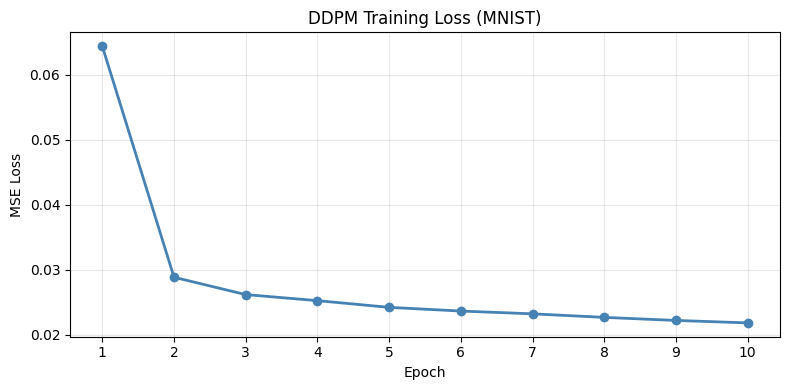

In [46]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o', linewidth=2, color='steelblue')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("DDPM Training Loss (MNIST)")
plt.xticks(range(1, EPOCHS + 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
@torch.no_grad()
def p_sample(model, x_t, t_val, schedule):
    t_tensor = torch.full((x_t.size(0),), t_val, device=device, dtype=torch.long)


    eps_theta = model(x_t, t_tensor)
    beta_t          = schedule.betas[t_val]
    alpha_t         = schedule.alphas[t_val]
    alpha_bar_t     = schedule.alphas_cumprod[t_val]
    sqrt_recip_alpha = (1.0 / torch.sqrt(alpha_t))

    coeff    = beta_t / torch.sqrt(1.0 - alpha_bar_t)
    mean     = sqrt_recip_alpha * (x_t - coeff * eps_theta)

    if t_val == 0:
        return mean
    else:
        posterior_var = schedule.posterior_variance[t_val]
        z = torch.randn_like(x_t)
        return mean + torch.sqrt(posterior_var) * z


@torch.no_grad()
def generate_images(model, schedule, n_samples=16, img_size=28):
    model.eval()
    x = torch.randn(n_samples, 1, img_size, img_size, device=device)

    for t_val in tqdm(reversed(range(T)), desc="Sampling", total=T):
        x = p_sample(model, x, t_val, schedule)

    return x

Sampling: 100%|██████████| 1000/1000 [00:07<00:00, 142.07it/s]


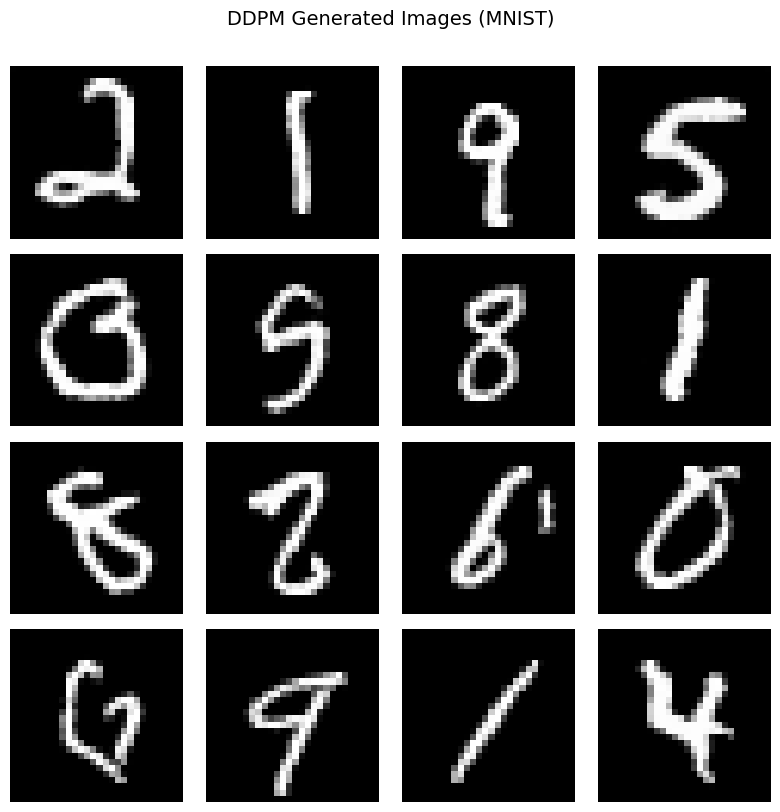

In [ ]:
generated = generate_images(model, schedule, n_samples=16)
generated_np = (generated.cpu().clamp(-1, 1).numpy() * 0.5 + 0.5)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated_np[i, 0], cmap='gray', vmin=0, vmax=1)
    ax.axis('off')

plt.suptitle("DDPM Generated Images (MNIST)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

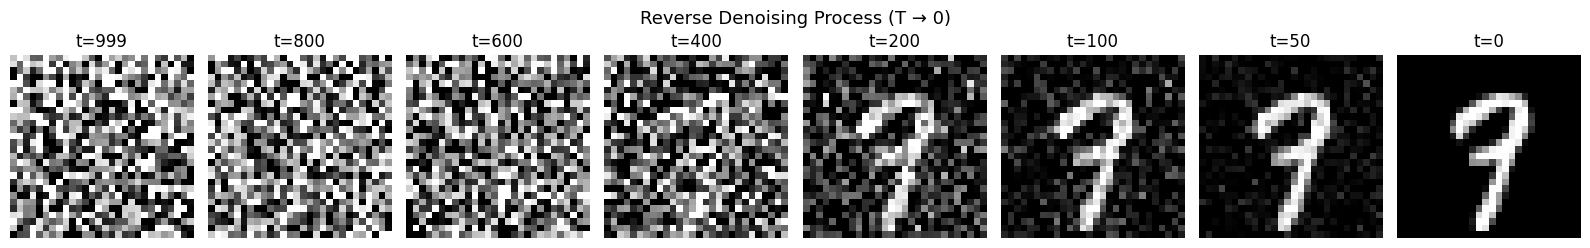

In [ ]:
@torch.no_grad()
def generate_with_history(model, schedule, img_size=28, steps_to_capture=None):
    if steps_to_capture is None:
        steps_to_capture = [999, 800, 600, 400, 200, 100, 50, 0]

    x = torch.randn(1, 1, img_size, img_size, device=device)
    history = {}

    for t_val in reversed(range(T)):
        x = p_sample(model, x, t_val, schedule)
        if t_val in steps_to_capture:
            img = x[0, 0].cpu().numpy() * 0.5 + 0.5
            history[t_val] = np.clip(img, 0, 1)

    return history


model.eval()
history = generate_with_history(model, schedule)

steps_to_show = sorted(history.keys(), reverse=True)
fig, axes = plt.subplots(1, len(steps_to_show), figsize=(16, 2.5))
for ax, t_val in zip(axes, steps_to_show):
    ax.imshow(history[t_val], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"t={t_val}")
    ax.axis('off')

plt.suptitle("Reverse Denoising Process (T → 0)", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
torch.save({
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses'        : train_losses,
    'epochs'              : EPOCHS,
}, 'ddpm_mnist.pth')
print("Model saved to ddpm_mnist.pth")


Model saved to ddpm_mnist.pth
